# try model LSTM for 1h, 1d, fear and greed

# Import Libraries



In [10]:
import tensorflow as tf
# سطر للتأكد من أن الكارت مرئي فعلاً
gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    print(f"Success! GPU found: {gpu_devices}")
else:
    print("Still not working. Check PATH or CUDA version.")

Still not working. Check PATH or CUDA version.


In [1]:
import numpy as np
import pandas as pd
import joblib
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils import class_weight

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv1D, MaxPooling1D, LSTM, Bidirectional, 
                                     Dense, Dropout, BatchNormalization, MultiHeadAttention, 
                                     GlobalAveragePooling1D, LayerNormalization, Add)
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

2026-03-07 23:50:36.837211: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-07 23:50:36.840883: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-07 23:50:37.229286: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-07 23:50:40.049115: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

# Load Data

In [2]:
df_hourly = pd.read_csv("data/BTC_ALL_HOURLY.csv")
df_daily = pd.read_csv("data/BTC_all_daily.csv")
df_fng = pd.read_csv("data/Fear_Greed_Daily.csv")
df_macro = pd.read_csv("data/Macro_Data_Daily.csv")

In [3]:
for d in [df_hourly, df_daily, df_fng, df_macro]:
    d['datetime'] = pd.to_datetime(d['datetime'])
    d.sort_values('datetime', inplace=True)

In [4]:
df = pd.merge_asof(df_hourly, df_daily[['datetime', 'close']], on='datetime', direction='backward', suffixes=('', '_daily'))
df = pd.merge_asof(df, df_fng, on='datetime', direction='backward')
df = pd.merge_asof(df, df_macro, on='datetime', direction='backward')


In [5]:
print("Data Loaded Successfully. Shape:", df.shape)

Data Loaded Successfully. Shape: (74836, 10)


In [6]:
print(f"Missing values before cleaning:\n{df.isnull().sum()}")
df.sort_index(inplace=True)

Missing values before cleaning:
datetime               0
open                   0
high                   0
low                    0
close                  0
volume                 0
close_daily            0
Fear_Greed_Index    4021
DXY                    0
SP500                  0
dtype: int64


In [7]:
df.dropna(inplace=True)
print(f"Missing values after cleaning:\n{df.isnull().sum()}")

Missing values after cleaning:
datetime            0
open                0
high                0
low                 0
close               0
volume              0
close_daily         0
Fear_Greed_Index    0
DXY                 0
SP500               0
dtype: int64


# Data Exploration (EDA)


In [8]:
df.head()


,datetime,open,high,low,close,volume,close_daily,Fear_Greed_Index,DXY,SP500
4021,2018-02-01 00:00:00,10285.10,10335.00,10215.07,10263.18,594.441290,9170.540039,30.0,88.669998,2821.97998
4022,2018-02-01 01:00:00,10263.18,10328.98,10216.00,10247.49,591.515725,9170.540039,30.0,88.669998,2821.97998
4023,2018-02-01 02:00:00,10249.43,10317.73,10176.89,10199.61,479.412562,9170.540039,30.0,88.669998,2821.97998
4024,2018-02-01 03:00:00,10199.61,10250.79,9959.04,10069.80,739.435309,9170.540039,30.0,88.669998,2821.97998
4025,2018-02-01 04:00:00,10069.77,10256.00,10000.01,10245.79,649.939854,9170.540039,30.0,88.669998,2821.97998


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70815 entries, 4021 to 74835
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   datetime          70815 non-null  datetime64[us]
 1   open              70815 non-null  float64       
 2   high              70815 non-null  float64       
 3   low               70815 non-null  float64       
 4   close             70815 non-null  float64       
 5   volume            70815 non-null  float64       
 6   close_daily       70815 non-null  float64       
 7   Fear_Greed_Index  70815 non-null  float64       
 8   DXY               70815 non-null  float64       
 9   SP500             70815 non-null  float64       
dtypes: datetime64[us](1), float64(9)
memory usage: 5.4 MB


In [10]:
df.describe()


,datetime,open,high,low,close,volume,close_daily,Fear_Greed_Index,DXY,SP500
count,70815,70815.000000,70815.000000,70815.000000,70815.000000,70815.000000,70815.000000,70815.000000,70815.000000,70815.000000
mean,2022-02-19 13:56:51.192544,38458.283241,38611.659134,38297.279907,38459.107776,2701.007947,38489.053513,46.567394,99.040061,4222.963529
min,2018-02-01 00:00:00,3172.620000,3184.750000,3156.260000,3172.050000,0.000000,3236.761719,5.000000,88.589996,2237.399902
25%,2020-02-12 09:30:00,9500.570000,9538.875000,9452.520000,9500.015000,827.999391,9525.750977,27.000000,95.550003,3066.590088
50%,2022-02-20 07:00:00,28503.710000,28605.150000,28376.110000,28504.360000,1474.187870,28454.978516,46.000000,98.279999,4124.080078
75%,2024-02-27 23:30:00,59583.940000,59845.050000,59318.965000,59584.500000,2841.440770,59498.792969,65.000000,103.419998,5026.609863
max,2026-03-06 15:00:00,126011.180000,126199.630000,125252.740000,126011.180000,137207.188600,124752.531250,95.000000,114.110001,6978.600098
std,NaN,32559.031168,32659.219432,32455.052930,32559.063283,3960.594331,32554.496524,21.899006,5.229312,1224.654028


# Feature Engineering

In [11]:
print("Engineering 15 Professional Features")

Engineering 15 Professional Features


### EMA

In [12]:
df['EMA_10'] = df['close'].ewm(span=10).mean()
delta = df['close'].diff()
gain = delta.where(delta > 0, 0).rolling(14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
df['RSI'] = 100 - (100 / (1 + (gain / (loss + 1e-9))))

## Momentum Indicators

In [13]:
if 'DXY' in df.columns:
    df['DXY_ret'] = df['DXY'].pct_change()
if 'SP500' in df.columns:
    df['SP500_ret'] = df['SP500'].pct_change()

## Returns

In [14]:
df['close_ret'] = df['close'].pct_change()
df['volume_ret'] = df['volume'].pct_change()

## Target

In [15]:
df['Target'] = (df['close'].shift(-24) > df['close']).astype(int)
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

In [18]:
final_features = [
    'close_ret', 'volume_ret', 'EMA_10', 'RSI', 
    'Fear_Greed_Index', 
    'DXY_ret', 'SP500_ret' # ميزات الماكرو
]

### test

In [16]:
df.describe()


,datetime,open,high,low,close,volume,close_daily,Fear_Greed_Index,DXY,SP500,EMA_10,RSI,DXY_ret,SP500_ret,close_ret,volume_ret,Target
count,70799,70799.000000,70799.000000,70799.000000,70799.000000,70799.000000,70799.000000,70799.000000,70799.000000,70799.000000,70799.000000,70799.000000,70799.000000,70799.000000,70799.000000,70799.000000,70799.000000
mean,2022-02-19 20:47:35.481009,38463.995293,38617.382484,38302.986109,38464.831013,2701.256201,38494.889206,46.569853,99.042064,4223.247727,38461.013783,50.777911,0.000002,0.000015,0.000053,0.152402,0.518312
min,2018-02-01 13:00:00,3172.620000,3184.750000,3156.260000,3172.050000,0.000000,3236.761719,5.000000,88.589996,2237.399902,3192.089210,0.547546,-0.021167,-0.119841,-0.182115,-1.000000,0.000000
25%,2020-02-12 19:30:00,9499.905000,9538.160000,9452.050000,9500.000000,828.074018,9525.750977,27.000000,95.565002,3066.590088,9497.800863,39.332153,0.000000,0.000000,-0.002382,-0.270326,0.000000
50%,2022-02-20 14:00:00,28506.990000,28620.000000,28381.000000,28508.620000,1474.328682,28478.484375,46.000000,98.279999,4124.080078,28493.864106,50.675244,0.000000,0.000000,0.000067,-0.034663,1.000000
75%,2024-02-28 03:30:00,59587.335000,59850.000000,59336.185000,59589.705000,2841.994002,59504.132812,65.000000,103.419998,5026.609863,59621.250697,62.151389,0.000000,0.000000,0.002540,0.310857,1.000000
max,2026-03-06 15:00:00,126011.180000,126199.630000,125252.740000,126011.180000,137207.188600,124752.531250,95.000000,114.110001,6978.600098,125062.361818,100.000000,0.016525,0.095154,0.173840,155.308443,1.000000
std,NaN,32560.196265,32660.389606,32456.202817,32560.218489,3960.890638,32555.503819,21.899443,5.227884,1224.633821,32557.190451,16.502840,0.000713,0.002088,0.007040,0.984378,0.499668


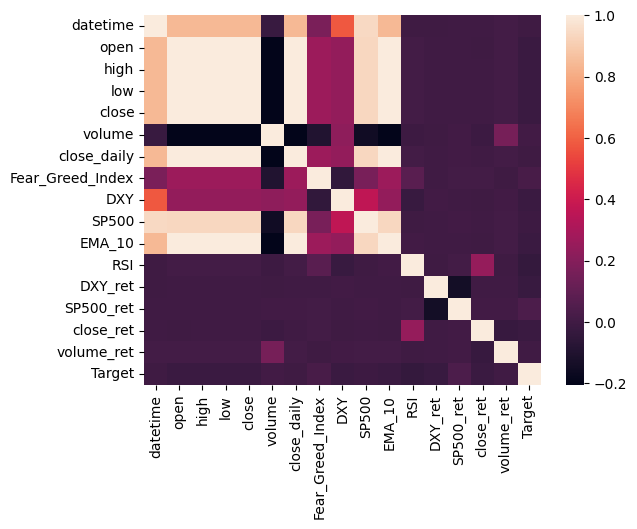

In [17]:
sns.heatmap(df.corr())
plt.show()
# !pip install seaborn

# Data Scaling

In [19]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df[final_features])
joblib.dump(scaler, "egx360_scaler_v3.pkl")

['egx360_scaler_v3.pkl']

In [20]:
split = int(len(X_scaled) * 0.8)
X_train_raw, X_test_raw = X_scaled[:split], X_scaled[split:]
y_train_raw, y_test_raw = df['Target'].values[:split], df['Target'].values[split:]

In [21]:
def create_sequences(data, target, seq_len=72):
    xs, ys = [], []
    for i in range(len(data) - seq_len):
        xs.append(data[i : i + seq_len])
        ys.append(target[i + seq_len])
    return np.array(xs), np.array(ys)

X_train, y_train = create_sequences(X_train_raw, y_train_raw)
X_test, y_test = create_sequences(X_test_raw, y_test_raw)

In [22]:
def build_hybrid_model(input_shape):
    inputs = Input(shape=input_shape)
    
    # [A] CNN Layer: لاستخراج الأنماط المكانية (Candlestick Patterns)
    x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)
    
    # [B] Bi-LSTM Layer: لفهم التسلسل الزمني والاعتماديات طويلة المدى
    x = Bidirectional(LSTM(128, return_sequences=True))(x)
    x = LayerNormalization()(x)
    
    # [C] Multi-Head Attention: للتركيز على الساعات الأكثر تأثيراً في الماضي
    attention_out = MultiHeadAttention(num_heads=4, key_dim=128)(x, x)
    x = Add()([x, attention_out])
    
    # [D] Dense Head: اتخاذ القرار النهائي
    x = GlobalAveragePooling1D()(x)
    x = Dense(64, activation='swish')(x)
    x = Dropout(0.4)(x)
    
    outputs = Dense(1, activation='sigmoid')(x)
    return Model(inputs, outputs)

model = build_hybrid_model((X_train.shape[1], X_train.shape[2]))
model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

E0000 00:00:1772920456.469228   30629 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1772920456.496476   30629 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


# Train Model

In [23]:
weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
cw_dict = {i: weights[i] for i in range(len(weights))}

callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ModelCheckpoint("EGX360_V3_Macro.keras", save_best_only=True),
    ReduceLROnPlateau(factor=0.5, patience=5)
]

print("🚀 Training Hybrid Model...")
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), 
                    epochs=100, batch_size=32, class_weight=cw_dict, callbacks=callbacks)

🚀 Training Hybrid Model...
Epoch 1/100
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 644s 347ms/step - accuracy: 0.5195 - loss: 0.7024 - val_accuracy: 0.4889 - val_loss: 0.7697 - learning_rate: 1.0000e-04
Epoch 2/100
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 686s 388ms/step - accuracy: 0.5386 - loss: 0.6910 - val_accuracy: 0.4943 - val_loss: 0.7083 - learning_rate: 1.0000e-04
Epoch 3/100
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 758s 429ms/step - accuracy: 0.5571 - loss: 0.6822 - val_accuracy: 0.5034 - val_loss: 0.7509 - learning_rate: 1.0000e-04
Epoch 4/100
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 643s 364ms/step - accuracy: 0.5706 - loss: 0.6734 - val_accuracy: 0.4911 - val_loss: 0.8428 - learning_rate: 1.0000e-04
Epoch 5/100
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 580s 328ms/step - accuracy: 0.5876 - loss: 0.6621 - val_accuracy: 0.4927 - val_loss: 0.7640 - learning_rate: 1.0000e-04
Epoch 6/100
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 585s 331ms/step - accuracy: 0.6057 - loss: 0.6486 - val_accuracy: 0.4952 - val_loss: 0.7953 - learning_rate: 1.0000

# Evaluate Model

In [50]:
y_probs = model.predict(X_test)
final_preds = (y_probs > 0.50).astype(int)

441/441 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step


In [51]:
print("\n Final Classification Report (Baseline V1):")
print(classification_report(y_test, final_preds, target_names=['Down', 'Up']))


 Final Classification Report (Baseline V1):
              precision    recall  f1-score   support

        Down       0.50      0.56      0.53      6904
          Up       0.52      0.46      0.49      7183

    accuracy                           0.51     14087
   macro avg       0.51      0.51      0.51     14087
weighted avg       0.51      0.51      0.51     14087



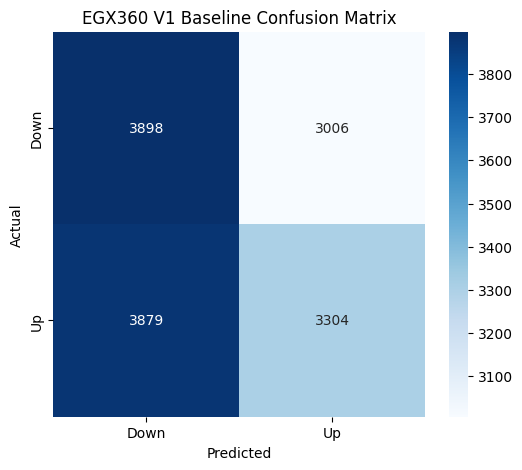

In [52]:
cm = confusion_matrix(y_test, final_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'])
plt.title("EGX360 V1 Baseline Confusion Matrix")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()